In [258]:
import sys
import os
from collections import namedtuple
from pathlib import Path
import json
import datetime
from enum import IntEnum, auto

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as pltpatches
import scipy.io

from tqdm.notebook import tqdm

import torch
import torch.nn as tnn
import torch.nn.functional as tnnf
import torch.optim as topt
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter

sys.path.append('..')
from lib.utils import *
from lib.logging import *

2025-12-18 22:57:23.965239: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-18 22:57:23.999291: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-18 22:57:25.040765: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


# Setup

In [251]:
config = namedtuple('Config', 'data_path')(
    data_path=Path('..') / 'data' / 'sparsenet'
)

LOG = Logging()
RNG = np.random.default_rng()
IS_CUDA = torch.cuda.is_available()
CUDA_DEVICE = torch.device("cuda" if IS_CUDA else "cpu")

print(f'CUDA_DEVICE={CUDA_DEVICE}')

with open(get_ipython().kernel.config['IPKernelApp']['connection_file'], 'r') as cf:
    notebook_fname = json.load(cf)['jupyter_session']
    notebook_fname = os.path.basename(notebook_fname)

print(notebook_fname)

CUDA_DEVICE=cpu
s2_denoising_ae_01.ipynb


# Images

In [3]:
def add_images_to_lib(images, tag):
    IMAGES_LIB[tag] = dict(images=images, image_stds=images.reshape(images.shape[0], -1).std(axis=1))

In [4]:
IMAGES_LIB = {
    'RAW': dict(fname='IMAGES_RAW.mat', mat_name='IMAGESr'),
    'WHITENED': dict(fname='IMAGES.mat', mat_name='IMAGES'),
}

for k in IMAGES_LIB:
    fname = IMAGES_LIB[k]['fname']
    mat_name = IMAGES_LIB[k]['mat_name']
    mat = scipy.io.loadmat(config.data_path / fname)
    images = mat[mat_name]
    images = np.moveaxis(images, [2], [0])
    add_images_to_lib(images, k)

# Patching

In [40]:
ImagePatch = namedtuple('ImagePatch', 'patch image_ind i_off j_off')

def extract_image_patch(images, patch_size, image_ind=None, image_stds=None, rng=None):
    blind_area = 4
    trials = 1000
    rng = RNG if rng is None else rng
    image_ind = rng.choice(len(images)) if image_ind is None else image_ind
    image = images[image_ind]

    with_std = not image_stds is None
    
    if with_std:
        image_std_thres = image_stds[image_ind] * .1

    for _ in range(trials):
        i_off = blind_area + rng.choice(image.shape[0] - 2 * blind_area - patch_size)
        j_off = blind_area + rng.choice(image.shape[1] - 2 * blind_area - patch_size)
        patch = image[i_off:i_off + patch_size, j_off:j_off + patch_size]
        
        if with_std:
            patch_std = patch.ravel().std()
    
            if patch_std < image_std_thres:
                continue
        
        break
    else:
        assert False, f'Failed to extract image patch within {trials} trials'
    
    return ImagePatch(patch, image_ind, i_off, j_off)

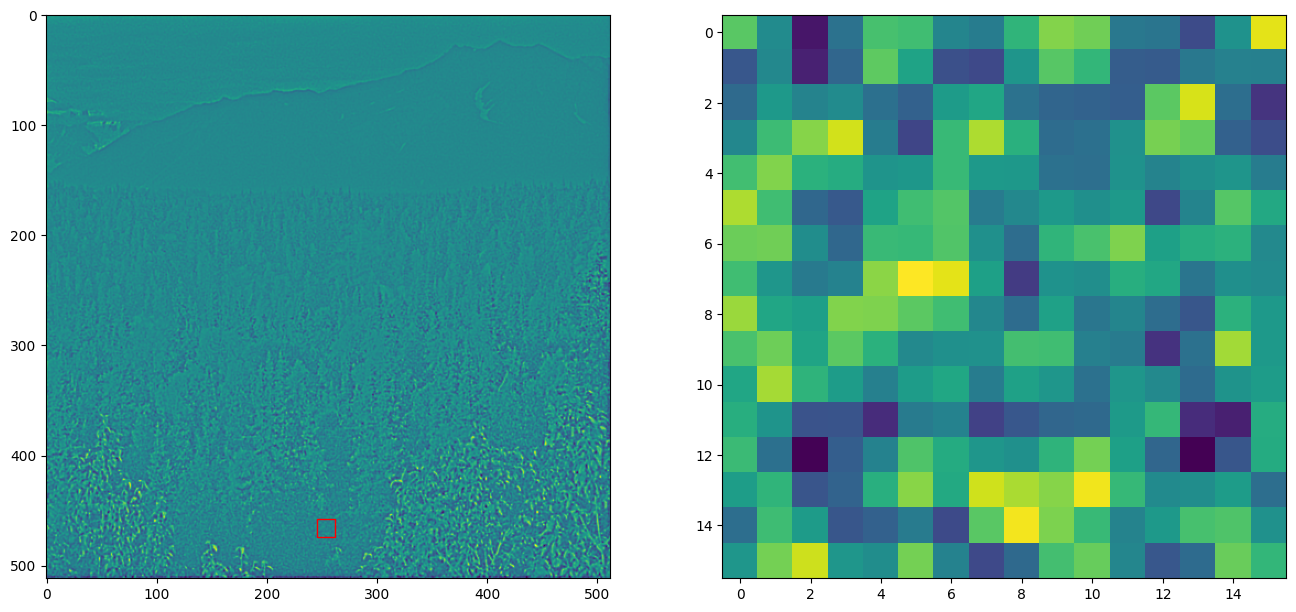

In [51]:
# slot = IMAGES_LIB['RAW']
slot = IMAGES_LIB['WHITENED']
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2) = plt.subplots(1, 2)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.imshow(images[image_ind]);
rect = pltpatches.Rectangle((j_off, i_off), patch.shape[1], patch.shape[0], linewidth=1, edgecolor='r', facecolor='none')
ax1.add_patch(rect)
ax2.imshow(patch);

# Noising

In [92]:
def gauss_noise(patch, σ, rng=None):
    save_shape = patch.shape
    patch = patch.ravel()
    rng = RNG if rng is None else rng
    result = patch + rng.normal(0, σ, len(patch))
    # result = rng.multivariate_normal(patch, σ * np.eye(len(patch)))
    return result.reshape(save_shape)

def masking_noise(patch, ν, rng=None):
    assert 0 <= ν <= 1
    save_shape = patch.shape
    patch = patch.ravel()
    rng = RNG if rng is None else rng
    inds = rng.choice(len(patch), int(ν * len(patch)), replace=False)
    result = patch.copy()
    result[inds] = 0
    return result.reshape(save_shape)

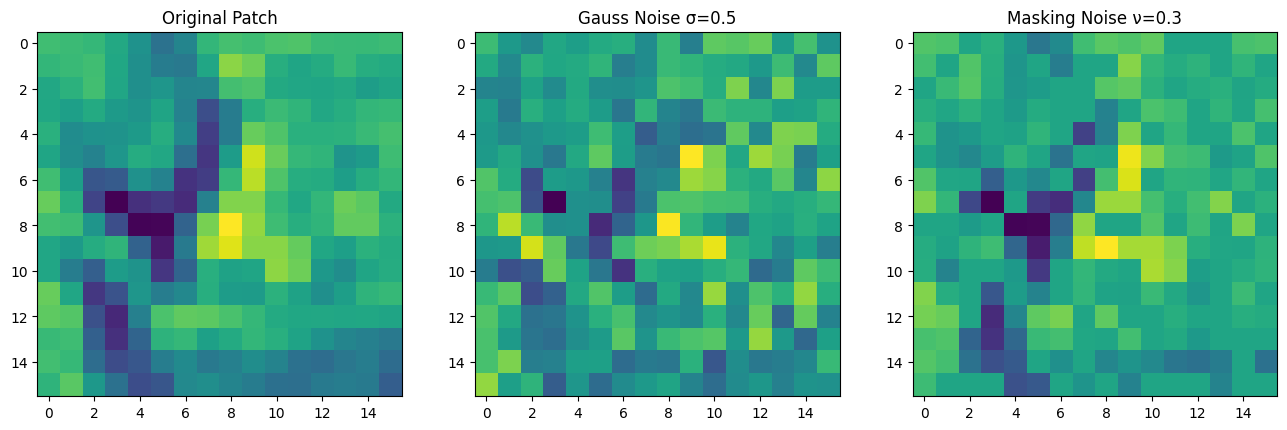

In [112]:
# slot = IMAGES_LIB['RAW']
slot = IMAGES_LIB['WHITENED']
patch, image_ind, i_off, j_off = extract_image_patch(slot['images'], 16)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3)
fig.set_figwidth(16)
fig.set_figheight(8)
ax1.set_title('Original Patch')
ax1.imshow(patch);
σ = 0.5
ax2.set_title(f'Gauss Noise σ={σ}')
ax2.imshow(gauss_noise(patch, σ));
ν = 0.3
ax3.set_title(f'Masking Noise ν={ν}')
ax3.imshow(masking_noise(patch, ν));

# Dataset

In [152]:
NoiseType = namedtuple('NoiseType', 'mnem func')
dataset_rng = np.random.default_rng(82)

HP_DATASET_SIZE = 10_000
HP_PATCH_SIZE = 12
HP_NOISE = NoiseType('Gauss', lambda p: gauss_noise(p, σ=0.5, rng=dataset_rng))
# HP_NOISE = NoiseType('Masking', lambda p: masking_noise(p, ν=0.1, rng=dataset_rng))

In [153]:
images = IMAGES_LIB['WHITENED']['images']
dataset = []

for i in range(HP_DATASET_SIZE):
    patch = extract_image_patch(images, HP_PATCH_SIZE, rng=dataset_rng).patch
    noised_patch = HP_NOISE.func(patch)
    dataset.append((noised_patch.ravel(), patch.ravel())) # X (noised) and Y (clean)

dataset = torch.Tensor(np.array(dataset))

In [254]:
%%timeit
dataLoader = DataLoader(dataset, batch_size=100)

for batch in dataLoader:
    pass

10.8 ms ± 325 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


# Model

In [244]:
class DenoiseAutoencoder(tnn.Module):
    def __init__(self, inp_dims_count, hiddens_count):
        super().__init__()
        self.filters = tnn.Linear(inp_dims_count, hiddens_count)
        self.decoder = tnn.Linear(hiddens_count, inp_dims_count)

        bound = 1 / np.sqrt(inp_dims_count)
        self.filters.weight.data.uniform_(-bound, bound)
        bound = 1 / np.sqrt(hiddens_count)
        self.decoder.weight.data.uniform_(-bound, bound)

    def forward(self, inp):
        out = tnnf.sigmoid(self.filters(inp))
        out = self.decoder(out)
        return out

In [255]:
model = DenoiseAutoencoder(144, 200)
sum([p.numel() for p in model.parameters()])

57944

In [256]:
dataLoader = DataLoader(dataset, batch_size=100)
model(next(iter(dataLoader))[:,0,...]).shape

torch.Size([100, 144])

# Training

We trained both regular autoencoders and denoising autoencoders on 12×12 patches from whitened natural scene images, made available by Olshausen (Olshausen and Field, 1996)... 

For these natural image patches, we used a linear decoder and a squared reconstruction cost. Network parameters were trained from a random start, using stochastic gradient descent to perform 500000 weight updates with a fixed learning rate of 0.05. All filters shown were from experiments with tied weights, but untied weights yielded similar results.

We then trained 200 hidden units over-complete noiseless autoencoders regularized with L2 weight decay, as well as 200 hidden units denoising autoencoders with isotropic Gaussian noise (but no weight decay). ... With a sufficiently large noise level however (σ = 0.5), the denoising autoencoder learns Gabor-like local oriented edge detectors 

In [247]:
HP_FILTERS_COUNT = 200
HP_BATCH_SIZE = 100
HP_EPOCHS_COUNT = 3
HP_LEARN_RATE = 0.05

In [259]:
metrics_dir = os.path.join('run', datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S'))
metrics_writer = SummaryWriter(log_dir=metrics_dir)

model = DenoiseAutoencoder(HP_PATCH_SIZE**2, HP_FILTERS_COUNT).to(device=CUDA_DEVICE)
dataLoader = DataLoader(dataset, batch_size=HP_BATCH_SIZE, pin_memory=IS_CUDA, shuffle=True)
optimizer = topt.Adam(model.parameters(), lr=HP_LEARN_RATE)
loss_fn = tnn.MSELoss()

for epoch in tqdm(range(HP_EPOCHS_COUNT)):
    loss_train = 0
    
    for batch in dataLoader:
        noised_data = batch[:,0,...].to(device=CUDA_DEVICE)
        true_data = batch[:,1,...].to(device=CUDA_DEVICE)
        infer_data = model(noised_data)
        loss = loss_fn(infer_data, true_data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        loss_train += loss.item()
    
    metrics_writer.add_scalar('loss', loss_train / len(dataLoader))

  0%|          | 0/3 [00:00<?, ?it/s]

In [28]:
# Ca. config for "Olshausen et al. Emergence of simple-cell receptive field properties by learning a sparse code for natural images"
# HP_IMAGES_SLOT = 'WHITENED'
# HP_PATCH_SIZE = 16
# HP_BASE_FUNCS_COUNT = 192
# HP_TRIALS_COUNT = 4_000

# HP_EXTR_PATCH_WITH_STD = False
# HP_NOISE_VAR = 0.01   # noise variance (sigma_N^2 in Vision Research paper, eq. 6)
# HP_BETA = 2.2         # steepness of prior (beta in Vision Research paper, eq. 8)
# HP_SIGMA = 0.316      # scaling parameter for prior (sigma in Nature paper)
# HP_TOL = 0.01         # tolerance for conjugate gradient routine
# HP_MAX_ITER = 100
# HP_ETA_SCHEDULE = np.full(HP_TRIALS_COUNT, 1) # learning rate (eta in Nature/Vision Research paper)
# HP_COEFFS_VAR_GOAL = 0.1
# HP_VAR_ETA = 0.001    # average rate for S_var
# HP_ALPHA = 0.02       # gain adaptation rate

# # # Ca. config for "Olshausen et al. Sparse Coding with an Overcomplete Basis Set: A Strategy Employed by V1"
# HP_IMAGES_SLOT = 'WHITENED'
# HP_PATCH_SIZE = 12
# HP_BASE_FUNCS_COUNT = 144
# HP_TRIALS_COUNT = 2_000

# HP_EXTR_PATCH_WITH_STD = True
# HP_NOISE_VAR = 0.01   # noise variance (sigma_N^2 in Vision Research paper, eq. 6)
# HP_BETA = 2.2         # steepness of prior (beta in Vision Research paper, eq. 8)
# HP_SIGMA = 0.316      # scaling parameter for prior (sigma in Nature paper)
# HP_TOL = 0.01         # tolerance for conjugate gradient routine
# HP_MAX_ITER = 100
# HP_ETA_SCHEDULE = np.full(HP_TRIALS_COUNT, 1) # learning rate (eta in Nature/Vision Research paper)
# HP_ETA_SCHEDULE[:600] = 5
# HP_ETA_SCHEDULE[600:1200] = 2.5
# HP_COEFFS_VAR_GOAL = 0.1
# HP_VAR_ETA = 0.001    # average rate for S_var
# HP_ALPHA = 0.02       # gain adaptation rate

# Mine
HP_IMAGES_SLOT = 'ZCA_WHITENED12'
# HP_IMAGES_SLOT = 'RAW'
HP_PATCH_SIZE = 12
HP_BASE_FUNCS_COUNT = 200
HP_TRIALS_COUNT = 2_000

HP_EXTR_PATCH_WITH_STD = False
HP_NOISE_VAR = 0.01   # noise variance (sigma_N^2 in Vision Research paper, eq. 6)
HP_BETA = 2.2         # steepness of prior (beta in Vision Research paper, eq. 8)
HP_SIGMA = 0.316      # scaling parameter for prior (sigma in Nature paper)
HP_TOL = 0.01         # tolerance for conjugate gradient routine
HP_MAX_ITER = 100
HP_ETA_SCHEDULE = np.full(HP_TRIALS_COUNT, 1) # learning rate (eta in Nature/Vision Research paper)
HP_COEFFS_VAR_GOAL = 0.1
HP_VAR_ETA = 0.001    # average rate for S_var
HP_ALPHA = 0.02       # gain adaptation rate

# ==============
HP_BATCH_SIZE = 100

In [29]:
metrics_dir = os.path.join('run', datetime.datetime.now().strftime('%Y-%m-%dT%H:%M:%S'))
metrics_writer = SummaryWriter(log_dir=metrics_dir)

# each base is a COLUMN vector!
bases = RNG.uniform(0, 1, (HP_PATCH_SIZE ** 2, HP_BASE_FUNCS_COUNT)) - 0.5
bases_norm = np.linalg.norm(bases, axis=0)
bases = bases / bases_norm
 
coeffs_var = HP_COEFFS_VAR_GOAL * np.ones(HP_BASE_FUNCS_COUNT) # actual variance of the coefficients, aka a_i variance
gain = np.linalg.norm(bases, axis=0)

images = IMAGES_LIB[HP_IMAGES_SLOT]['images']
image_stds = IMAGES_LIB[HP_IMAGES_SLOT]['image_stds']

for trial_no in tqdm(range(HP_TRIALS_COUNT)):
    image_ind = RNG.choice(len(images))
    patches = []

    for _ in range(HP_BATCH_SIZE):
        patch = extract_image_patch(images, image_stds, HP_PATCH_SIZE, image_ind, with_std=HP_EXTR_PATCH_WITH_STD)
        patches.append(patch.patch)

    # each patch is a COLUMN vector!
    patches = np.array(patches)
    patches = patches.reshape(len(patches), -1) # e.g. (100, 12, 12) -> (100, 144)
    patches = patches.T

    # calculate coefficients (referred to a_i in article) for these patches: row - base func, col - image patch
    coeffs = fit_bases(bases, patches, HP_NOISE_VAR, HP_BETA, HP_SIGMA, HP_TOL, HP_MAX_ITER)
    # assert np.all(np.any(coeffs, axis=0))

    # calculate residual error, shape the same as patches
    reconstr_patches = bases @ coeffs
    residual_error = patches - reconstr_patches

    metrics_writer.add_scalar('res_err_sum', residual_error.sum(), trial_no)
    metrics_writer.add_scalar('res_err_mean', residual_error.sum(axis=0).mean(), trial_no)

    # update bases
    # This yields the learning rule: Δϕ_i = η<a_i*r> (в статье есть опечатка в формуле 17 - пропущена закрывающая скобка перед знаком "равно"),
    # where η is the learning rate. In terms of the network implementation shown in Fig. 5, the ϕ_i are updated by simple Hebbian learning between 
    # the outputs computed for each image, a_i, and the resulting residual image, r. Note: <...> - means averaging.
    # Т.к. a_i можно рассматривать как реакцию нейрона (хитрожопая реакция, нелинейная), 
    # то правило обучения Хебба тут прям один в один (w_i(n+1) = w_i(n) + η * y(n) * x_i(n)) с единственным замечанием, 
    # что x_i(n) есть не исходный сигнал (картинка), а остаточная картинка
    delta_bases = np.zeros_like(bases)

    for i in range(HP_BATCH_SIZE):
        # outer product of two vectors: 1) redisual_error column vector for patch, 2) coeffs row vector for patch
        delta_bases_for_patch = residual_error[:,i][:,np.newaxis] @ coeffs[:,i][np.newaxis,:]
        delta_bases = delta_bases + delta_bases_for_patch

    delta_bases /= HP_BATCH_SIZE

    η = HP_ETA_SCHEDULE[trial_no]
    bases = bases + η * delta_bases
    
    # normalize bases in a classical way to prevent them from growing infinitely large
    bases_norm = np.linalg.norm(bases, axis=0)
    bases /= bases_norm

    # adjust bases to match desired output variance for each a_i
    # As mentioned above, though, doing this alone will result in the ϕ_i growing without bound, 
    # and so to prevent this from happening the L2 norm of each basis function, l_i^2 = Σϕ_i^2, 
    # is separately adapted so that the output variance of each a_i is held at an appropriate level
    # 1) В оригинальном sparsenet эта операция была объединена с нормализацией, т.е. bases *= gain / bases_norm
    # Здесь для лучшего понимания логика была разделена явно (нормализация выше, корректировка здесь).
    # 2) Похоже здесь предполагается, что среднее значение каждого из a_i равно 0, иначе не объяснить,
    # почему дисперсия считается просто как квадрат
    # 3) Здесь по ходу решается задача a-la backprop. У нас есть наблюдаемая дисперсия a_i, есть желаемая дисперсия a_i, 
    # что надо сделать, чтобы наблюдаемая дисперсия была близко в желаемой? Повлиять на дисперсию
    # можно только через ϕ_i, т.к. a_i есть по-сути реакция нейрона (вычисляемая хрень), поэтому ничего не остаётся как делать
    # вот такой вот странноватый backward update (пятимся назад)
    for i in range(HP_BATCH_SIZE):
        # update coeffs_var (aka a_i variance) via recursive average filter idiom
        coeffs_var = (1 - HP_VAR_ETA) * coeffs_var + HP_VAR_ETA * (coeffs[:,i]**2)

    # С такой формулой gain будет потихоньку расти для coeffs_var > HP_COEFFS_VAR_GOAL и уменьшаться
    # наоборот. Значит ϕ_i, у которых var(a_i) > HP_COEFFS_VAR_GOAL  будет получать небольшую прибавку и наоборот (см. график ниже)
    # В sparsenet-tcl такая же логика только без деления: gain[i] += 0.1*(a_var[i]-VAR_GOAL), и при этом 
    # там в контексте overlap ещё это рассматривается
    gain *= (coeffs_var / HP_COEFFS_VAR_GOAL) ** HP_ALPHA
    bases *= gain


  0%|          | 0/2000 [00:00<?, ?it/s]

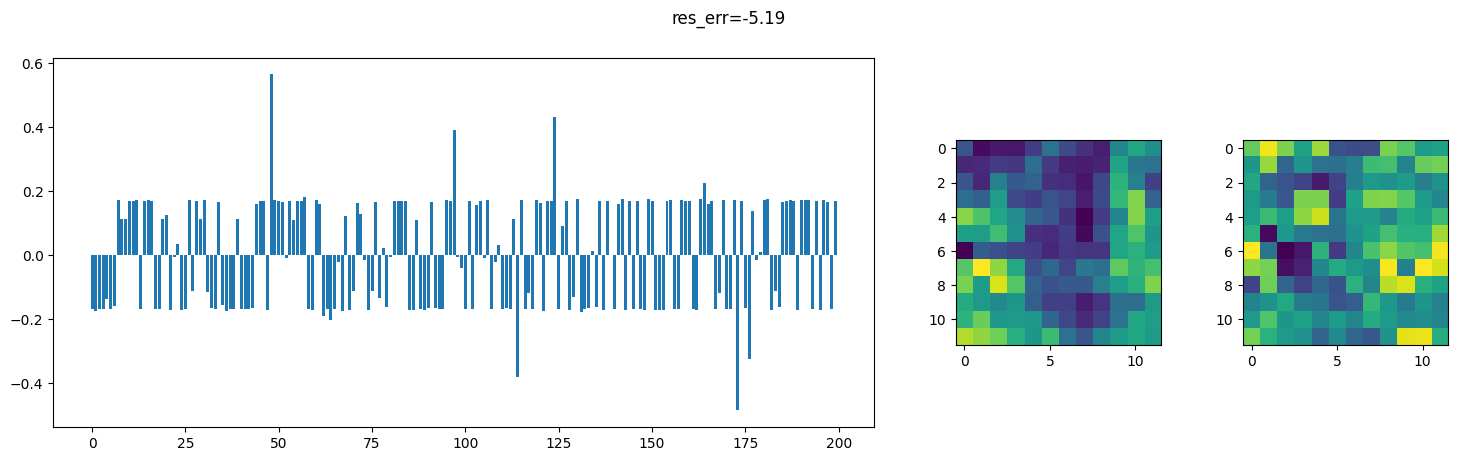

In [34]:
i = RNG.choice(patches.shape[1])
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, gridspec_kw={'width_ratios': [4, 1, 1]})
fig.set_figwidth(18)
ax1.bar(np.arange(len(coeffs)), coeffs[:,i])
ax2.imshow(vec_to_square_matrix(patches[:,i]))
ax3.imshow(vec_to_square_matrix(reconstr_patches[:,i]))
plt.suptitle(f'res_err={(patches[:,i] - reconstr_patches[:,i]).sum():.2f}');

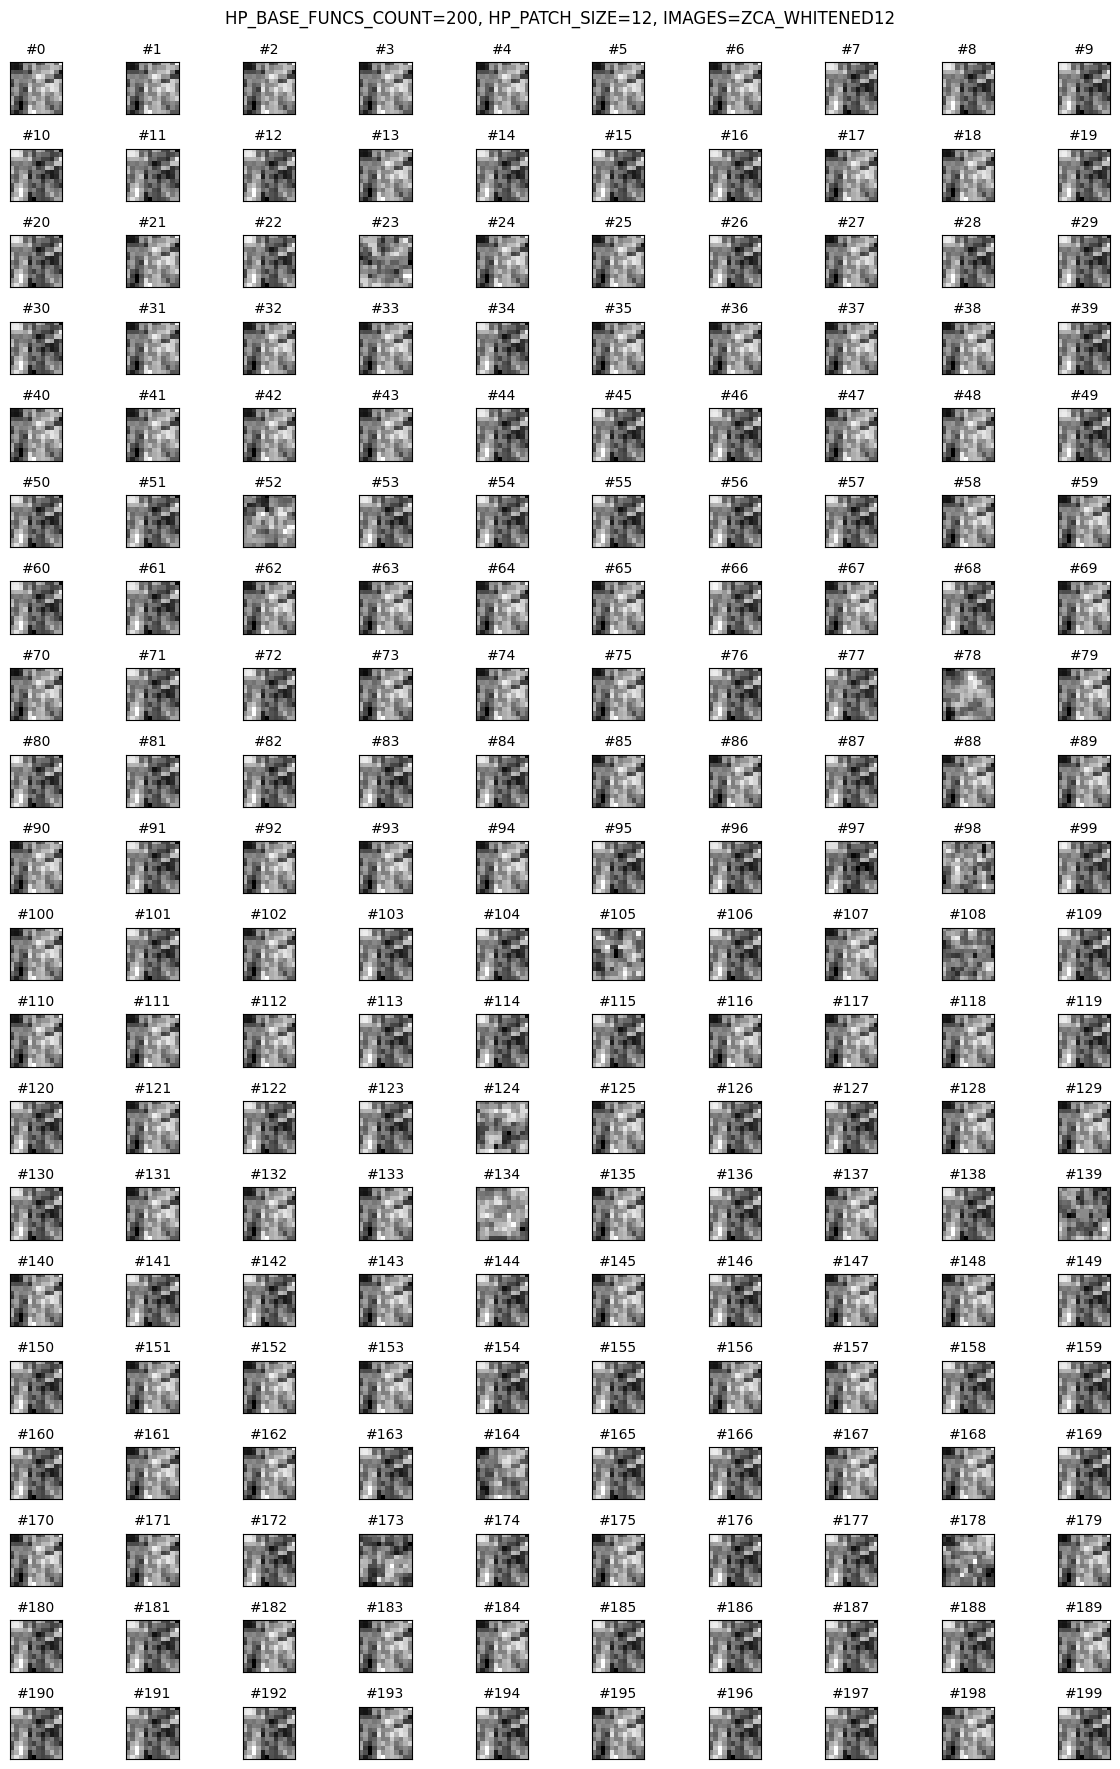

In [35]:
bases_in_row = 10
fig, axes = plt.subplots(int(np.ceil(HP_BASE_FUNCS_COUNT / bases_in_row)), bases_in_row)
fig.set_figwidth(12)
fig.set_figheight(18)

for i, (base, ax) in enumerate(zip(bases.T, axes.ravel())):
    ax.set_title(f'#{i}', fontdict=dict(fontsize=10))
    ax.imshow(vec_to_square_matrix(base), cmap='gray')
    ax.set_xticks([])
    ax.set_yticks([])

fig.suptitle(f'HP_BASE_FUNCS_COUNT={HP_BASE_FUNCS_COUNT}, HP_PATCH_SIZE={HP_PATCH_SIZE}, IMAGES={HP_IMAGES_SLOT}\n')
plt.tight_layout()

# Results